# PV NPV simulation

Run the PV electricity Monte Carlo simulation and visualize the resulting NPV distribution.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from electricity.electricity_npv_monte_carlo import simulate_pv_npv


In [2]:
SAMPLE_SIZE = 1000000
#RANDOM_SEED = 42

rng = np.random.default_rng() 
simulation = simulate_pv_npv(size=SAMPLE_SIZE, rng=rng)
results = pd.DataFrame(simulation)

results.head()

,run_id,technology,annual_output_mwh,full_load_hours_per_year,capacity_mw,capacity_kw,capex_eur_per_kw,fixed_opex_eur_per_kw_year,variable_opex_eur_per_mwh,fuel_consumption_mwh_th_per_mwh_e,...,annual_revenue_eur,annual_fixed_opex_eur,annual_variable_opex_eur,annual_fuel_cost_eur,annual_emissions_cost_eur,annual_net_cash_flow_eur,npv_eur,lifetime_output_mwh,npv_eur_per_mwh,npv_million_eur_per_mwh
0,0,pv,1000000.0,1107.5,902.934537,902934.537246,813.023150,15.957516,0.0,0.0,...,94070000.0,1.440859e+07,0.0,0.0,0.0,7.966141e+07,1.162610e+08,25000000.0,4.650441,0.000005
1,1,pv,1000000.0,1107.5,902.934537,902934.537246,806.382463,13.696785,0.0,0.0,...,94070000.0,1.236730e+07,0.0,0.0,0.0,8.170270e+07,1.440475e+08,25000000.0,5.761898,0.000006
2,2,pv,1000000.0,1107.5,902.934537,902934.537246,735.284088,13.843497,0.0,0.0,...,94070000.0,1.249977e+07,0.0,0.0,0.0,8.157023e+07,2.068305e+08,25000000.0,8.273221,0.000008
3,3,pv,1000000.0,1107.5,902.934537,902934.537246,856.371562,13.519092,0.0,0.0,...,94070000.0,1.220686e+07,0.0,0.0,0.0,8.186314e+07,1.006233e+08,25000000.0,4.024932,0.000004
4,4,pv,1000000.0,1107.5,902.934537,902934.537246,745.166858,12.295420,0.0,0.0,...,94070000.0,1.110196e+07,0.0,0.0,0.0,8.296804e+07,2.128284e+08,25000000.0,8.513135,0.000009


In [3]:
npv_million_eur = results["npv_eur"] / 1_000_000
npv_eur_per_mwh = results["npv_eur_per_mwh"]
npv_million_eur_per_mwh = results["npv_million_eur_per_mwh"]

summary = pd.concat(
    [
        npv_million_eur.describe(percentiles=[0.05, 0.5, 0.95]).rename(
            "NPV million EUR"
        ),
        npv_eur_per_mwh.describe(percentiles=[0.05, 0.5, 0.95]).rename(
            "NPV EUR/MWh"
        ),
        npv_million_eur_per_mwh.describe(percentiles=[0.05, 0.5, 0.95]).rename(
            "NPV million EUR/MWh"
        ),
    ],
    axis=1,
)
summary


,NPV million EUR,NPV EUR/MWh,NPV million EUR/MWh
count,1000000.000000,1000000.000000,1000000.000000
mean,149.451577,5.978063,0.000006
std,53.795778,2.151831,0.000002
min,26.263983,1.050559,0.000001
5%,65.484206,2.619368,0.000003
50%,149.429379,5.977175,0.000006
95%,233.739111,9.349564,0.000009
max,268.654513,10.746181,0.000011


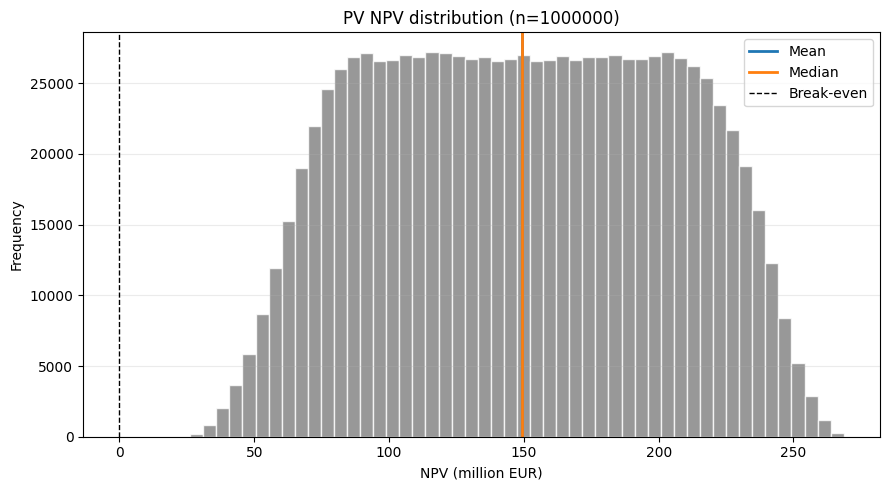

In [4]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(npv_million_eur, bins=50, color="tab:gray", edgecolor="white", alpha=0.8)
ax.axvline(npv_million_eur.mean(), color="tab:blue", linewidth=2, label="Mean")
ax.axvline(npv_million_eur.median(), color="tab:orange", linewidth=2, label="Median")
ax.axvline(0, color="black", linewidth=1, linestyle="--", label="Break-even")

ax.set_title(f"PV NPV distribution (n={SAMPLE_SIZE})")
ax.set_xlabel("NPV (million EUR)")
ax.set_ylabel("Frequency")
ax.grid(axis="y", alpha=0.25)
ax.legend()

fig.tight_layout()
plt.show()

## NPV per MWh histogram


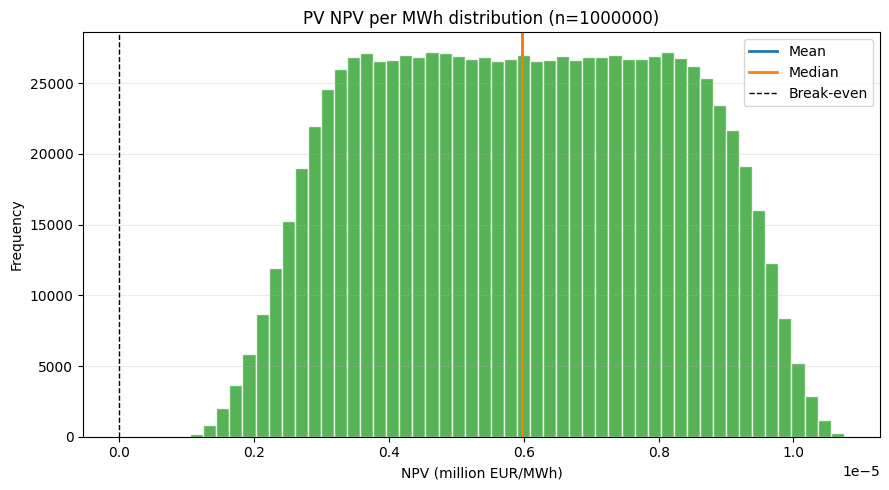

In [5]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(
    npv_million_eur_per_mwh,
    bins=50,
    color="tab:green",
    edgecolor="white",
    alpha=0.8,
)
ax.axvline(
    npv_million_eur_per_mwh.mean(),
    color="tab:blue",
    linewidth=2,
    label="Mean",
)
ax.axvline(
    npv_million_eur_per_mwh.median(),
    color="tab:orange",
    linewidth=2,
    label="Median",
)
ax.axvline(0, color="black", linewidth=1, linestyle="--", label="Break-even")

ax.set_title(f"PV NPV per MWh distribution (n={SAMPLE_SIZE})")
ax.set_xlabel("NPV (million EUR/MWh)")
ax.set_ylabel("Frequency")
ax.grid(axis="y", alpha=0.25)
ax.legend()

fig.tight_layout()
plt.show()


In [6]:
annual_components = results[
    [
        "annual_revenue_eur",
        "annual_fixed_opex_eur",
        "annual_variable_opex_eur",
        "annual_fuel_cost_eur",
        "annual_emissions_cost_eur",
        "annual_net_cash_flow_eur",
    ]
] / 1_000_000

annual_components.mean().rename("Mean annual value, million EUR")

annual_revenue_eur           94.070000
annual_fixed_opex_eur        12.400016
annual_variable_opex_eur      0.000000
annual_fuel_cost_eur          0.000000
annual_emissions_cost_eur     0.000000
annual_net_cash_flow_eur     81.669984
Name: Mean annual value, million EUR, dtype: float64